In [1]:
! pip install swig --quiet
! pip install "gymnasium[box2d]" --quiet


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import gymnasium as gym
from copy import deepcopy
import torch
import torch.optim as optim
import random

In [2]:
class BoltzmannPolicy:
    def __init__(self, actions: list):
        self.actions = actions
    
    def generate_action(self, Q_values: np.ndarray, temp: float = 0.1):
        if random.random() < temp:
            return np.random.choice(self.actions)
        else:
            return np.argmax(Q_values)

In [3]:
class QNetwork(nn.Module):
    def __init__(self, state_dim: int, num_actions: int, latent_dim: int = 64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, latent_dim),
            nn.GELU(),
            nn.Linear(latent_dim, latent_dim),
            nn.GELU(),
            nn.Linear(latent_dim, num_actions) # predict Q values for each action
        )

    def forward(self, state_tensor: torch.Tensor):
        return self.net(state_tensor)

In [4]:
class ReplayBuffer:
    def __init__(self, capacity: int = 100_000):
        self.capacity = capacity
        self.buffer = []

    def add(self, transition: tuple) -> None:
        if len(self.buffer) >= self.capacity:
            self.buffer.pop(0)
        
        self.buffer.append(transition)

    def __len__(self):
        return len(self.buffer)

    def sample(self, batch_size: int):
        return random.sample(self.buffer, batch_size)

In [5]:
# hyperparams
batch_size = 64
learning_rate = 5e-4
gamma = 0.99
num_episodes = 1200
target_update_steps = 1000
t_init = 0.5
t_min = 0.01
t_decay = 0.997
buffer_capacity = 100_000
num_warmup_episodes = 5_000

In [6]:
env = gym.make("LunarLander-v3")
state_dim = env.observation_space.shape[0]
action_dim = env.action_space.n

policy = BoltzmannPolicy(range(action_dim))
buffer = ReplayBuffer(capacity=buffer_capacity)

Q_model = QNetwork(state_dim, action_dim)
target_Q_model = deepcopy(Q_model)

optimizer = optim.Adam(Q_model.parameters(), lr=learning_rate)

total_steps = 0
temp = t_init

In [7]:
loss_fn = torch.nn.HuberLoss()

In [8]:
def train_step():
    if len(buffer) < num_warmup_episodes:
        return
    
    batch = buffer.sample(batch_size)
    
    states, actions, rewards, next_states, terminateds = zip(*batch)
    
    states_t = torch.FloatTensor(np.array(states))
    actions_t = torch.LongTensor(actions).unsqueeze(1)
    rewards_t = torch.FloatTensor(rewards)
    next_states_t = torch.FloatTensor(np.array(next_states))
    terminateds_t = torch.FloatTensor(terminateds)
    current_q = Q_model(states_t).gather(1, actions_t).squeeze(1)
    
    with torch.no_grad():
        next_actions = Q_model(next_states_t).argmax(dim=1, keepdim=True)
        next_q_values = target_Q_model(next_states_t).gather(1, next_actions).squeeze(1)
        targets = rewards_t + gamma * next_q_values * (1 - terminateds_t)
        
    loss = loss_fn(current_q, targets)
    
    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(Q_model.parameters(), max_norm=1.0)
    optimizer.step()

In [9]:
for episode_num in range(num_episodes):
    state, info = env.reset()
    done = False
    total_reward = 0
    
    temp = max(t_min, temp * t_decay)
    
    while not done:
        with torch.no_grad():
            state_t = torch.FloatTensor(state).unsqueeze(0)
            Q_values = Q_model(state_t).squeeze(0).numpy()
            
        action = policy.generate_action(Q_values, temp)
        
        next_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
        
        buffer.add((state, action, reward, next_state, terminated))
        
        train_step()
        
        state = next_state
        total_reward += reward
        total_steps += 1
        
        if total_steps % target_update_steps == 0:
            target_Q_model.load_state_dict(Q_model.state_dict())
            
    if (episode_num + 1) % 10 == 0:
        print(f"Эпизод {episode_num + 1}. Температура: {temp:.3f}. Награда: {total_reward:.2f}")
    
env.close()

Эпизод 10. Температура: 0.485. Награда: -332.08
Эпизод 20. Температура: 0.471. Награда: -259.05
Эпизод 30. Температура: 0.457. Награда: -455.77
Эпизод 40. Температура: 0.443. Награда: -508.65
Эпизод 50. Температура: 0.430. Награда: -154.08
Эпизод 60. Температура: 0.418. Награда: -237.17
Эпизод 70. Температура: 0.405. Награда: -118.71
Эпизод 80. Температура: 0.393. Награда: -135.17
Эпизод 90. Температура: 0.382. Награда: -81.63
Эпизод 100. Температура: 0.370. Награда: -4.05
Эпизод 110. Температура: 0.359. Награда: 61.25
Эпизод 120. Температура: 0.349. Награда: -100.81
Эпизод 130. Температура: 0.338. Награда: -8.09
Эпизод 140. Температура: 0.328. Награда: -209.73
Эпизод 150. Температура: 0.319. Награда: -54.34
Эпизод 160. Температура: 0.309. Награда: 43.15
Эпизод 170. Температура: 0.300. Награда: 40.10
Эпизод 180. Температура: 0.291. Награда: 4.62
Эпизод 190. Температура: 0.283. Награда: 48.48
Эпизод 200. Температура: 0.274. Награда: 98.75
Эпизод 210. Температура: 0.266. Награда: 59.10
Э

Запуск оценки агента на 100 тест-эпизодах...
Тест: Эпизод 10/100 завершен. Награда: 268.09
Тест: Эпизод 20/100 завершен. Награда: -16.14
Тест: Эпизод 30/100 завершен. Награда: 241.00
Тест: Эпизод 40/100 завершен. Награда: 248.05
Тест: Эпизод 50/100 завершен. Награда: 29.51
Тест: Эпизод 60/100 завершен. Награда: 275.15
Тест: Эпизод 70/100 завершен. Награда: 251.40
Тест: Эпизод 80/100 завершен. Награда: 268.43
Тест: Эпизод 90/100 завершен. Награда: 244.83
Тест: Эпизод 100/100 завершен. Награда: 255.74

           РЕЗУЛЬТАТЫ ОЦЕНКИ           
Средняя награда (Mean Reward):  178.77 ± 110.13
Минимальный скор (Min):         -36.55
Максимальный скор (Max):         321.07
Успешных посадок (>= 200):      59.0%


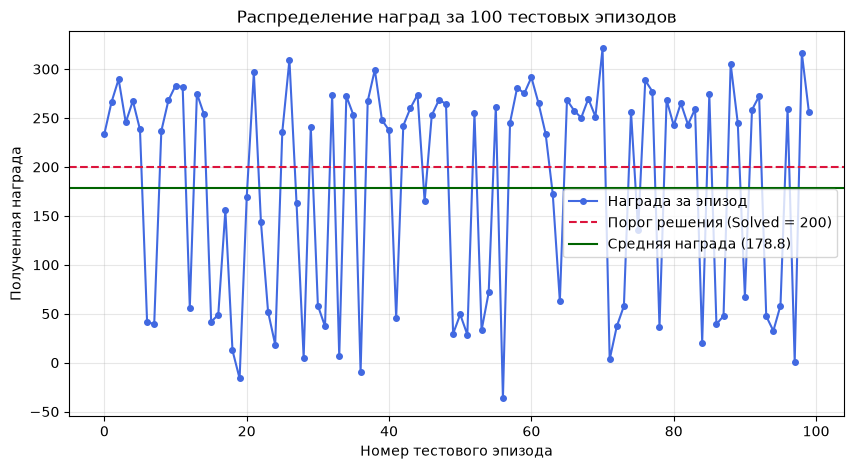

In [10]:
test_env = gym.make("LunarLander-v3")
num_eval_episodes = 100
eval_rewards = []

# Переводим модель в режим оценки
Q_model.eval()

print(f"Запуск оценки агента на {num_eval_episodes} тест-эпизодах...")

for episode in range(num_eval_episodes):
    state, info = test_env.reset()
    done = False
    episode_reward = 0
    
    while not done:
        # Во время теста выбираем строго жадное действие (greedy exploitation)
        with torch.no_grad():
            state_t = torch.FloatTensor(state).unsqueeze(0)
            Q_values = Q_model(state_t).squeeze(0).numpy()
            
        # Находим действие с наивысшей оценкой Q
        action = np.argmax(Q_values)
        
        next_state, reward, terminated, truncated, info = test_env.step(action)
        done = terminated or truncated
        
        state = next_state
        episode_reward += reward
        
    eval_rewards.append(episode_reward)
    
    if (episode + 1) % 10 == 0:
        print(f"Тест: Эпизод {episode + 1}/{num_eval_episodes} завершен. Награда: {episode_reward:.2f}")

test_env.close()

# 2. Расчет метрик
mean_reward = np.mean(eval_rewards)
std_reward = np.std(eval_rewards)
min_reward = np.min(eval_rewards)
max_reward = np.max(eval_rewards)

# Считаем долю успешных посадок (все, что выше порога решения в 200 очков)
success_rate = np.mean([1 if r >= 200 else 0 for r in eval_rewards]) * 100

print("\n" + "="*40)
print("           РЕЗУЛЬТАТЫ ОЦЕНКИ           ")
print("="*40)
print(f"Средняя награда (Mean Reward):  {mean_reward:.2f} ± {std_reward:.2f}")
print(f"Минимальный скор (Min):         {min_reward:.2f}")
print(f"Максимальный скор (Max):         {max_reward:.2f}")
print(f"Успешных посадок (>= 200):      {success_rate:.1f}%")
print("="*40)

# 3. Красивый график распределения наград
plt.figure(figsize=(10, 5))
plt.plot(eval_rewards, label="Награда за эпизод", color="royalblue", marker='o', markersize=4)
plt.axhline(y=200, color="crimson", linestyle="--", label="Порог решения (Solved = 200)")
plt.axhline(y=mean_reward, color="darkgreen", linestyle="-", label=f"Средняя награда ({mean_reward:.1f})")

plt.title(f"Распределение наград за {num_eval_episodes} тестовых эпизодов")
plt.xlabel("Номер тестового эпизода")
plt.ylabel("Полученная награда")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()